# Solution
***

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (summarize,ModelSpec as MS)

## a)
***

In [17]:
#Loading dataset
Auto = load_data('Auto')
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [18]:
#Design
design = MS(['horsepower'])
design = design.fit(Auto)
X = design.transform(Auto)
y = Auto['mpg']

In [ ]:
results = sm.OLS(y, X).fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [38]:
X_new = pd.DataFrame({'horsepower' : [98]})
X_new = design.transform(X_new)

In [ ]:
#Prediction for car with 98 horsepower
print(round(results.rsquared, 4))

print("Punctual prediction: ", results.predict(X_new).values)
print("Confidence interval: ", results.get_prediction(X_new).conf_int(alpha = 0.05))
print("Prediction interval: ", results.get_prediction(X_new).conf_int(obs = True, alpha = 0.05))

0.6059
Punctual prediction:  [24.46707715]
Confidence interval:  [[23.97307896 24.96107534]]
Prediction interval:  [[14.80939607 34.12475823]]


## Interpretation

- **i)** Yes, there is a clear relationship between the predictor and response. The p-value is equal to 0, indicating that we reject the null-hypothesis.

- **ii)** Horsepower explains approxametaly 60.6% of the variance in mpg.

- **iii)** The coeffisient is equal to $-0.1578$, indicating a negative relationship. An increase in horsepower means a reduction in mpg. 

- **iv)** The predicted mpg for a car with 98 horsepower is 24.47 mpg. The 95% confidence interval is [23.97, 24.96], meaning the average mpg for all cars with 98 horsepower lies within this range. The 95% prediction interval is [14.81, 34.12], meaning a single car with 98 horsepower will have an mpg within this range with 95% probability. The prediction interval is much wider than the confidence interval because it accounts for both the uncertainty in the regression line and the natural variation between individual cars.


## b)
***

<positron-console-cell-62>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


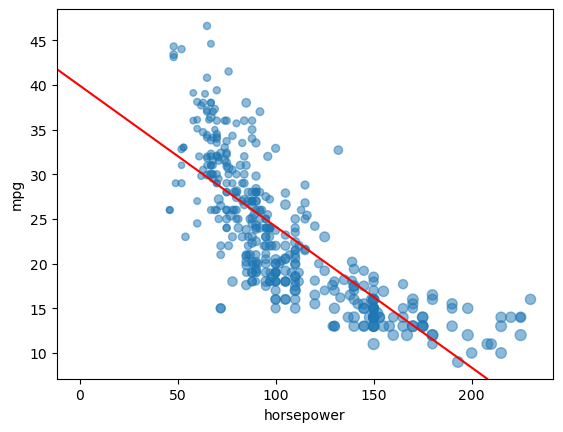

In [62]:
#Plotting response and predictor
fig, ax = plt.subplots()

#Scatterplot
Auto.plot.scatter('horsepower', 'mpg', ax = ax, s = Auto['weight']/80, alpha = 0.5)

#Regressionline
ax.axline(xy1 = (0, results.params[0]), slope = results.params[1], color = 'red')

plt.show()

## c)
***

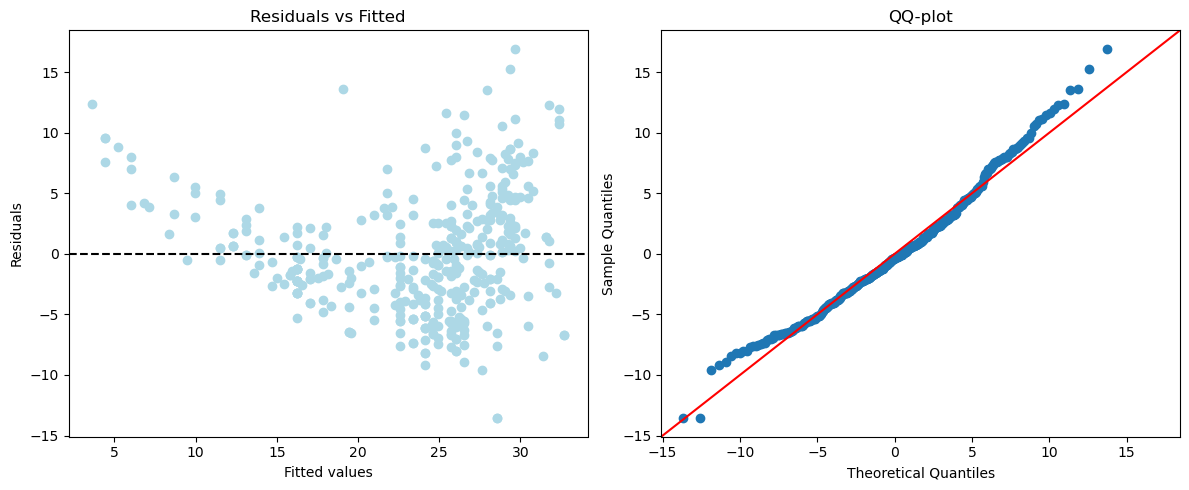

In [71]:
#Diagnostic plots
fig, ax = plt.subplots(1, 2, figsize = (12, 5))

ax[0].scatter(results.fittedvalues, results.resid, color = 'lightblue')
ax[0].axhline(0, color = 'black', ls = '--')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residuals vs Fitted')

#QQ-plot
sm.qqplot(results.resid, 
    line = '45', 
    loc = np.mean(results.resid),
    scale = np.std(results.resid),
    ax = ax[1]
)

ax[1].set_title('QQ-plot')

plt.tight_layout()
plt.show()

## Interpretation

The residual plot shows a clear U-shaped pattern — residuals are 
positive for low and high fitted values, and negative in the middle. 
This suggests a non-linear relationship between horsepower and mpg, 
meaning a straight line is not the best fit for this data.

The QQ-plot shows some deviation from normality in the tails, 
which may affect the reliability of prediction intervals.
